In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

In [9]:
from glob import glob
import numpy as np
import cv2
import os

dataset_path = r"D:\DP Larning\caltech-101"

# Ye wahi paths hain jo extract_features me jayenge
image_paths = glob(dataset_path + "/*/*.jpg")

print("Total Images:", len(image_paths))


images = []
labels = []

for img_path in image_paths:
    
    img = cv2.imread(img_path)

    if img is not None:
        
        resized_img = cv2.resize(img,(28,28))
        images.append(resized_img)

        label = os.path.basename(os.path.dirname(img_path))
        labels.append(label)


images = np.array(images)
labels = np.array(labels)

print(images.shape)
print(labels.shape)

Total Images: 9144
(9144, 28, 28, 3)
(9144,)


In [10]:
#Image Files List Dekho
from glob import glob

files = glob(r"D:\DP Larning\caltech-101\*\*.jpg")

print(len(files))

files[:20]

9144


['D:\\DP Larning\\caltech-101\\accordion\\image_0001.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0002.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0003.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0004.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0005.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0006.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0007.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0008.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0009.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0010.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0011.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0012.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0013.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0014.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0015.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0016.jpg',
 'D:\\DP Larning\\caltech-101\\accordion\\image_0017.jpg

(np.float64(-0.5), np.float64(259.5), np.float64(299.5), np.float64(-0.5))

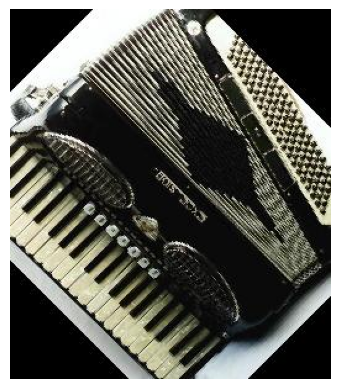

In [11]:
#Images Display Karo
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(files[0])

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

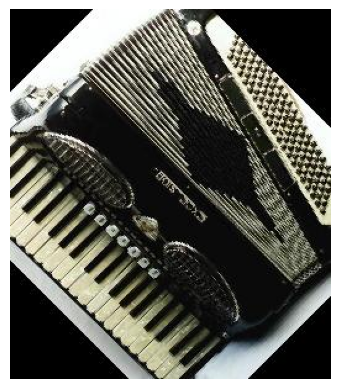

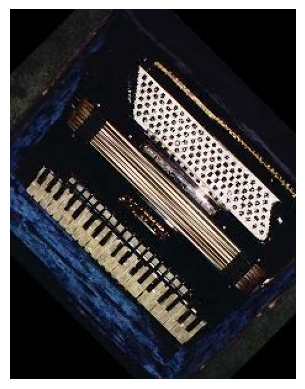

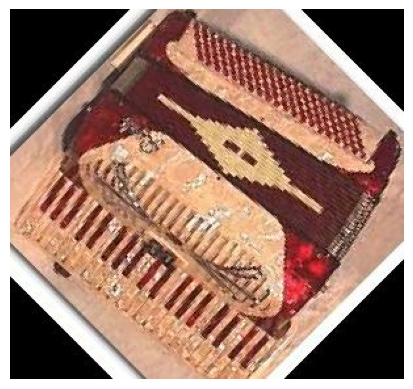

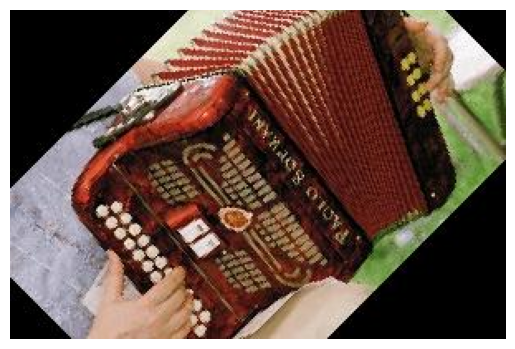

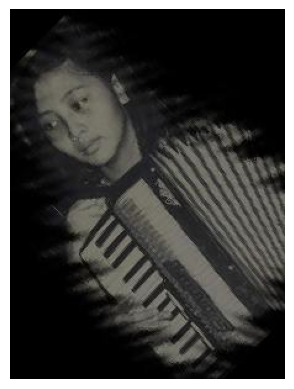

In [12]:
#Multiple Images Dekho
for i in range(5):
    
    img = cv2.imread(files[i])
    
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

**Importing Required Libraries**

In [13]:
import numpy as np 
from numpy.linalg import norm
import pickle
from tqdm import tqdm , tqdm_notebook
import os
import random 
import time
import math
import tensorflow as tf
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import PIL
from PIL import Image
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from  tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import glob
import matplotlib
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
%matplotlib inline

**Loading the ResNet50 model:**

In [14]:
model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3),
    pooling='avg'
)

In [15]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

**Feature Extraction**

In [16]:
def extract_features(img_path, model):

    # ResNet50 ke liye required input size (Height, Width, Channels)
    input_shape = (224,224,3)  

    # img_path se image load karte hain aur 224x224 me resize karte hain
    img = image.load_img(img_path,
                         target_size=(input_shape[0],input_shape[1]))

    # Image ko numpy array me convert karte hain (224,224,3)
    img_array = image.img_to_array(img)

    # Batch dimension add karte hain (1,224,224,3)
    expanded_img_array = np.expand_dims(img_array,axis=0)

    # ResNet50 ke format ke according preprocessing karte hain
    preprocessed_img = preprocess_input(expanded_img_array)

    # Image ko ResNet50 model me pass karke features nikalte hain
    features = model.predict(preprocessed_img)

    # Features ko 1D vector me convert karte hain
    flattened_features = features.flatten()

    # Feature vector ko normalize karte hain similarity ke liye
    normalized_features = flattened_features / norm(flattened_features)

    # Final feature vector return karte hain
    return normalized_features

**aab kya karege --> aab main ish(extraction_fratures) function ko sare image per apply karege**

In [18]:
features = extract_features(image_paths[0], model)
print("Total length of features for one image:", len(features))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Total length of features for one image: 2048


In [ ]:


# Allowed image extensions
extensions = ['.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG']


# Dataset folder se sabhi image file paths nikalne ka function
def get_file_list(root_dir):
    
    # Empty list jisme sab image paths store honge
    file_list = []
    
    # Dataset ke sab folders me recursively jana
    for root, directories, filenames in os.walk(root_dir):
        
        # Har folder ke andar ki files check karna
        for filename in filenames:
            
            # Check karna ki file image extension wali hai ya nahi
            if any(ext in filename for ext in extensions):
                
                # Folder path + filename ko jodkar full path banana
                filepath = os.path.join(root, filename)
                
                # Check karna file exist karti hai ya nahi
                if os.path.exists(filepath):
                    
                    # Agar file exist karti hai to list me add karo
                    file_list.append(filepath)
                    
                else:
                    
                    # Agar file missing hai to print karo
                    print(filepath)
    
    # Final image paths ki list return karo
    return file_list

In [ ]:
# Dataset folder ka path define karna
root_dir = r"D:\DP Larning\caltech-101"


# Dataset ke sabhi image file paths nikalna aur sorted order me rakhna
filenames = sorted(get_file_list(root_dir))


# Total images kitni hain wo print karna
print(len(filenames))

9144


In [24]:
# Ek batch me kitni images process hongi
BATCH_SIZE = 128


# Dataset folder se images batch form me load karna
generator = tf.keras.utils.image_dataset_from_directory(
    
    root_dir,            # Dataset ka main folder path
    
    shuffle=False,       # Order same rahega (important for similarity search)
    
    batch_size=BATCH_SIZE,   # Ek batch me 128 images
    
    image_size=(224,224)     # Sab images ko 224x224 resize karna
)


# Total images kitni hain dataset me
num_images = len(generator.file_paths)


# Total batches (steps) calculate karna
num_epochs = int(math.ceil(num_images / BATCH_SIZE))


# Feature extraction start hone ka time
start_time = time.time()


# Empty list (optional, yaha model.predict direct fill karega)
feature_list = []


# ResNet50 model se sab images ke features nikalna
feature_list = model.predict(generator, steps=num_epochs)


# Feature extraction end hone ka time
end_time = time.time()

Found 9144 files belonging to 102 classes.
72/72 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step


In [26]:
# Har image ke feature vector ko normalize karna
for i, features in enumerate(feature_list):
    
    # Feature vector ko normalize karte hain (length = 1)
    feature_list[i] = features / norm(features)


# Feature matrix ko reshape karna (2D format me lana)
feature_list = feature_list.reshape(len(feature_list), -1)

# Total images print karna
print("Num images = ", len(generator.file_paths))

# Feature matrix ka shape print karna
print("Shape of feature_list = ", feature_list.shape)

# Feature extraction ka total time minutes me print karna
print("Time taken in Min = ", (end_time - start_time)/60)

Num images =  9144
Shape of feature_list =  (9144, 2048)
Time taken in Min =  3.536276435852051


In [27]:
random_index = random.randint(0, num_images)

In [38]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5 , algorithm='brute' , metric='euclidean').fit(feature_list)
distances , indices = neighbors.kneighbors([feature_list[random_index]])



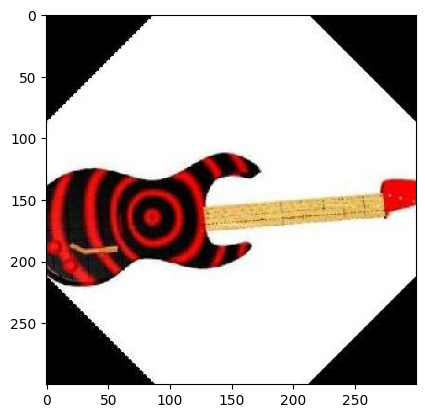

In [39]:
plt.imshow(mpimg.imread(filenames[random_index]))

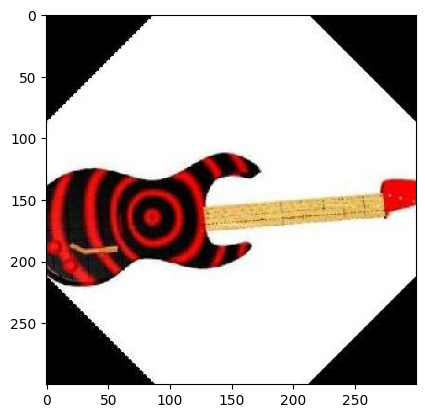

In [40]:
plt.imshow(mpimg.imread(filenames[indices[0][0]]))

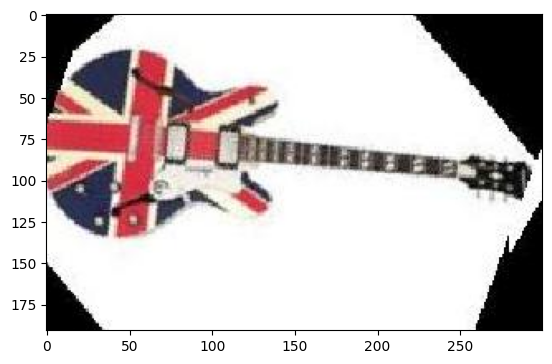

In [41]:
plt.imshow(mpimg.imread(filenames[indices[0][1]]))

**End-to-End Image Embedding Pipeline**

# End-to-End Image Embedding Pipeline

```
Image Input
    ↓
Preprocessing
    - Resize (224×224)
    - Convert to RGB
    - Normalize Pixels
    ↓
Feature Extraction
    - Pretrained CNN (ResNet50)
    - Remove Classification Layer
    ↓
Embedding Generation
    - 2048-D Vector Representation
    ↓
Embedding Normalization
    - L2 Normalization
    ↓
Embedding Storage
    - Feature List / Database
    ↓
Query Processing
    - Convert Query Image → Embedding
    ↓
Similarity Search
    - Euclidean Distance
    - Cosine Similarity
    ↓
Nearest Neighbor Retrieval
    - Top-K Similar Images
    ↓
Output Results
    - Similar Images
```


**Image → ResNet50 → Inside Processing**

```
Input Image (224×224×3)
        ↓
Convolution Layers
        ↓
Activation (ReLU)
        ↓
Batch Normalization
        ↓
Residual Blocks
        ↓
Feature Maps
        ↓
Global Average Pooling
        ↓
2048 Feature Vector
        ↓
Output Embedding
```